 # Data Cleaning , Preprocessing & Outlier Detection

## Import Libraries

In [92]:
import pandas as pd
import numpy as np

## Load Dataset

In [93]:
df = pd.read_csv('hotel_bookings.csv')
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## Dataset Overview

In [94]:
df.shape

(119390, 32)

In [95]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Handling Missing & Invalid Values

In [97]:
# Strip spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Replace NULL-like values
null_values = ['NULL', 'null', 'NaN', 'nan', 'None', '']
df = df.replace(null_values, np.nan)

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Missing Value Treatment

In [99]:
# Numerical
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [100]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,179.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Checking Duplicates

In [102]:
df.duplicated().sum()

np.int64(32013)

## Remove Duplicates

In [103]:
df = df.drop_duplicates()

In [104]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,179.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87377 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87377 non-null  object 
 1   is_canceled                     87377 non-null  int64  
 2   lead_time                       87377 non-null  int64  
 3   arrival_date_year               87377 non-null  int64  
 4   arrival_date_month              87377 non-null  object 
 5   arrival_date_week_number        87377 non-null  int64  
 6   arrival_date_day_of_month       87377 non-null  int64  
 7   stays_in_weekend_nights         87377 non-null  int64  
 8   stays_in_week_nights            87377 non-null  int64  
 9   adults                          87377 non-null  int64  
 10  children                        87377 non-null  float64
 11  babies                          87377 non-null  int64  
 12  meal                            8737

## Fix Data Types

In [106]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_21328\102017128.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,179.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Date Format Standardization

In [107]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'],
    format='%Y-%m-%d',   # enforce correct format
    errors='coerce'
)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87377 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87377 non-null  object        
 1   is_canceled                     87377 non-null  int64         
 2   lead_time                       87377 non-null  int64         
 3   arrival_date_year               87377 non-null  int64         
 4   arrival_date_month              87377 non-null  object        
 5   arrival_date_week_number        87377 non-null  int64         
 6   arrival_date_day_of_month       87377 non-null  int64         
 7   stays_in_weekend_nights         87377 non-null  int64         
 8   stays_in_week_nights            87377 non-null  int64         
 9   adults                          87377 non-null  int64         
 10  children                        87377 non-null  float64       
 11  babies

In [109]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,14.0,179.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,179.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,179.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Feature Engineering

In [110]:
df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['Revenue']=df['adr'] * df['total_stay']
df['Total_Previous_Bookings']=df['previous_cancellations'] + df['previous_bookings_not_canceled']
df['Cancellation_Rate']=df['previous_cancellations'] / (df['Total_Previous_Bookings'] + 1)
df['Booking_Change_Rate']=df['booking_changes'] / (df['lead_time'] + 1)

In [111]:
df['res_year'] = df['reservation_status_date'].dt.year
df['res_month'] = df['reservation_status_date'].dt.month
df['res_day'] = df['reservation_status_date'].dt.day
df['res_weekday'] = df['reservation_status_date'].dt.weekday

In [112]:
df['pricepernight'] = df['adr'] / (df['stays_in_weekend_nights'] + 1)

In [113]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_stay,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0.0,0,0.0,0.008746,2015,7,1,2,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0.0,0,0.0,0.005420,2015,7,1,2,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,75.0,0,0.0,0.000000,2015,7,2,3,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,1,75.0,0,0.0,0.000000,2015,7,2,3,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2,196.0,0,0.0,0.000000,2015,7,3,4,98.0


## Outlier Removal (IQR Method)

In [114]:
df_cleanednegative = df[df['adr'] >= 0]
df_cleanednegative.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87376 entries, 0 to 119389
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87376 non-null  object        
 1   is_canceled                     87376 non-null  int64         
 2   lead_time                       87376 non-null  int64         
 3   arrival_date_year               87376 non-null  int64         
 4   arrival_date_month              87376 non-null  object        
 5   arrival_date_week_number        87376 non-null  int64         
 6   arrival_date_day_of_month       87376 non-null  int64         
 7   stays_in_weekend_nights         87376 non-null  int64         
 8   stays_in_week_nights            87376 non-null  int64         
 9   adults                          87376 non-null  int64         
 10  children                        87376 non-null  float64       
 11  babies

In [115]:
df_cleanednegative['adr'].max()

5400.0

In [116]:
Q1 = df_cleanednegative['adr'].quantile(0.25)
Q3 = df_cleanednegative['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -21.0 Upper: 227.0


In [117]:
upper = df_cleanednegative['adr'].quantile(0.99)
lower = df_cleanednegative['adr'].quantile(0.01)

df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)

C:\Users\HP\AppData\Local\Temp\ipykernel_21328\2111461049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr'] = df_cleanednegative['adr'].clip(lower, upper)


In [118]:
# Optional: normalize
df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])

C:\Users\HP\AppData\Local\Temp\ipykernel_21328\2951147565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleanednegative['adr_log'] = np.log1p(df_cleanednegative['adr'])


In [119]:
df_cleanednegative

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,Revenue,Total_Previous_Bookings,Cancellation_Rate,Booking_Change_Rate,res_year,res_month,res_day,res_weekday,pricepernight,adr_log
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.00,0,0.0,0.008746,2015,7,1,2,0.000000,0.000000
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.00,0,0.0,0.005420,2015,7,1,2,0.000000,0.000000
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.00,0,0.0,0.000000,2015,7,2,3,75.000000,4.330733
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.00,0,0.0,0.000000,2015,7,2,3,75.000000,4.330733
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,196.00,0,0.0,0.000000,2015,7,3,4,98.000000,4.595120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,672.98,0,0.0,0.000000,2017,9,6,2,32.046667,4.576153
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,1578.01,0,0.0,0.000000,2017,9,7,3,75.143333,5.422436
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,1103.97,0,0.0,0.000000,2017,9,7,3,52.570000,5.067079
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,730.80,0,0.0,0.000000,2017,9,7,3,34.800000,4.657763


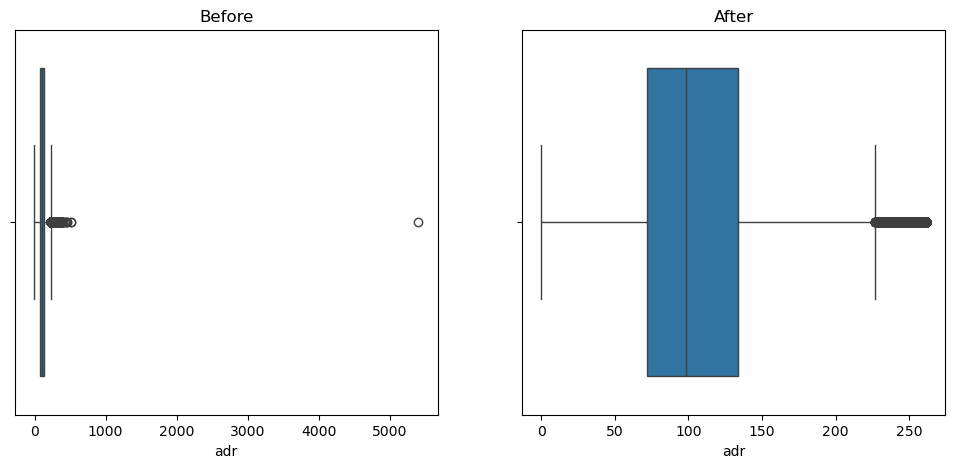

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleanednegative['adr'])
plt.title("After")

plt.show()

## Save Clean Dataset

In [121]:
df_cleanednegative.to_csv('cleaned_data.csv', index=False)